# Transformer 기반 한국어 챗봇

## 설계 원칙
- **토크나이저**: MeCab 단독 사용 (SentencePiece 중복 적용 X)
- **단어 사전**: 형태소 기반 커스텀 Vocab (word2idx / idx2word)
- **증강**: EDA (Random Deletion + Swap) → 원본 ~7,700개 × 4 = ~30,000개
- **특수 토큰**: PAD=0, UNK=1, BOS=2, EOS=3
- **공유 임베딩**: shared_emb=True


## Step 0. 환경 설정

In [1]:
# 패키지 설치
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "python-mecab-ko", "nltk", "-q"], capture_output=True)

# 한글 폰트 설치
import os, shutil, urllib.request
FONT_PATH = os.path.expanduser("~/.fonts/NanumGothic.ttf")
os.makedirs(os.path.dirname(FONT_PATH), exist_ok=True)
if not os.path.exists(FONT_PATH):
    try:
        urllib.request.urlretrieve(
            "https://github.com/naver/nanumfont/raw/master"
            "/NanumFontSetup_TTF_GOTHIC/NanumGothic.ttf", FONT_PATH)
        print("폰트 다운로드 완료")
    except:
        print("[주의] 폰트 다운로드 실패 - 한글이 깨질 수 있음")

print("설치 완료")


설치 완료


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import re, os, random, math
from collections import Counter
from tqdm.notebook import tqdm
from torch.utils.data import TensorDataset, DataLoader, random_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 설정 ─────────────────────────────
fm._load_fontmanager(try_read_cache=False)
if os.path.exists(FONT_PATH):
    _fe = fm.FontEntry(fname=FONT_PATH, name='NanumGothic')
    fm.fontManager.ttflist = [f for f in fm.fontManager.ttflist
                               if 'nanum' not in f.name.lower()]
    fm.fontManager.ttflist.insert(0, _fe)
    matplotlib.rc('font', family='NanumGothic')
    matplotlib.rcParams['axes.unicode_minus'] = False
    FONT_PROP = fm.FontProperties(fname=FONT_PATH, size=10)
    print("한글 폰트 적용 완료")
else:
    FONT_PROP = fm.FontProperties()

# ── 저장 경로 / 디바이스 ───────────────────────
SAVE_DIR = os.path.expanduser("~/work/노드실습/GoingDeeper/6.chatbot")
os.makedirs(SAVE_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | Device: {device}")
print(f"SAVE_DIR: {SAVE_DIR}")


한글 폰트 적용 완료
PyTorch: 2.7.1+cu118 | Device: cuda
SAVE_DIR: /home/jovyan/work/노드실습/GoingDeeper/6.chatbot


## Step 1. 데이터 로드

In [3]:
import urllib.request, zipfile

csv_path = os.path.join(SAVE_DIR, "ChatbotData.csv")
if not os.path.exists(csv_path):
    url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
    urllib.request.urlretrieve(url, csv_path)
    print("다운로드 완료")

df = pd.read_csv(csv_path)
questions = df['Q'].tolist()
answers   = df['A'].tolist()
print(f"총 데이터: {len(df):,}개")
print(df.head(3))


총 데이터: 11,823개
              Q            A  label
0        12시 땡!   하루가 또 가네요.      0
1   1지망 학교 떨어졌어    위로해 드립니다.      0
2  3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0


## Step 2. 데이터 전처리

In [4]:
def preprocess_sentence(sentence):
    """
    1. 영문 소문자 변환
    2. 한글/영문/숫자/주요 특수문자 외 제거
    3. 연속 공백 정규화
    """
    sentence = sentence.lower()
    sentence = re.sub(r'[^가-힣a-z0-9?.!,\s]', '', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence

# 동작 확인
print(preprocess_sentence("지루하다, 놀러가고 싶어!!"))
print(preprocess_sentence("Hello World~~ 안녕하세요 #test"))


지루하다, 놀러가고 싶어!!
hello world 안녕하세요 test


## Step 3. MeCab 토큰화 (단독 사용)

In [5]:
from mecab import MeCab

mecab  = MeCab()
MAX_LEN = 30  # 형태소 최대 길이

def build_corpus(src_sentences, tgt_sentences, max_len=MAX_LEN):
    """
    전처리 → MeCab 형태소 분석 → 길이 필터 → 중복 제거 (쌍 유지)
    SentencePiece 중복 적용 없이 MeCab 단독 사용.
    """
    que_corpus, ans_corpus = [], []
    seen_que, seen_ans = set(), set()

    for src, tgt in tqdm(zip(src_sentences, tgt_sentences),
                         total=len(src_sentences), desc="build_corpus"):
        src_c = preprocess_sentence(src)
        tgt_c = preprocess_sentence(tgt)

        src_tok = mecab.morphs(src_c)
        tgt_tok = mecab.morphs(tgt_c)

        # 길이 필터
        if len(src_tok) == 0 or len(tgt_tok) == 0:
            continue
        if len(src_tok) >= max_len or len(tgt_tok) >= max_len:
            continue

        # 소스/타겟 각각 독립적으로 중복 검사 (쌍 유지)
        if src_c in seen_que or tgt_c in seen_ans:
            continue

        seen_que.add(src_c)
        seen_ans.add(tgt_c)
        que_corpus.append(src_tok)
        ans_corpus.append(tgt_tok)

    print(f"원본: {len(src_sentences):,} → 필터링 후: {len(que_corpus):,}")
    return que_corpus, ans_corpus

que_corpus, ans_corpus = build_corpus(questions, answers)
print(f"\n샘플 Q: {que_corpus[0]}")
print(f"샘플 A: {ans_corpus[0]}")


build_corpus:   0%|          | 0/11823 [00:00<?, ?it/s]

원본: 11,823 → 필터링 후: 7,726

샘플 Q: ['12', '시', '땡', '!']
샘플 A: ['하루', '가', '또', '가', '네요', '.']


## Step 4. 데이터 증강 (EDA)

**선택 이유:** 챗봇 데이터는 Q-A 쌍의 뉘앙스가 중요합니다.  
Lexical Substitution은 유사어로 단어를 바꾸는데, 한국어 구어체 챗봇 데이터에서는
의미가 미묘하게 달라져 오히려 성능이 저하될 수 있습니다.  
EDA(Easy Data Augmentation)의 **Random Deletion + Random Swap**은  
형태소 수준에서 노이즈를 추가하여 모델 강건성을 높이고,  
원래 뉘앙스를 크게 해치지 않아 챗봇 데이터에 더 안정적입니다.

증강 구성:
- ① 원본
- ② Q 랜덤 삭제 + 원본 A  
- ③ 원본 Q + A 랜덤 삭제  
- ④ Q 랜덤 교환 + 원본 A  
→ 총 4배 (~30,000개)


In [6]:
def eda_deletion(tokens, p=0.15):
    """형태소 중 일부를 확률 p로 삭제"""
    if len(tokens) <= 2:
        return tokens
    result = [t for t in tokens if random.random() > p]
    return result if result else tokens

def eda_swap(tokens, n=1):
    """형태소 중 n쌍의 위치를 랜덤 교환"""
    result = tokens.copy()
    for _ in range(n):
        if len(result) < 2:
            break
        i, j = random.sample(range(len(result)), 2)
        result[i], result[j] = result[j], result[i]
    return result

def augment_corpus(que_corpus, ans_corpus):
    aug_que = que_corpus.copy()
    aug_ans = ans_corpus.copy()

    # ② Q 삭제 + 원본 A
    for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus), desc="② Q 삭제"):
        aug_que.append(eda_deletion(q))
        aug_ans.append(a)

    # ③ 원본 Q + A 삭제
    for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus), desc="③ A 삭제"):
        aug_que.append(q)
        aug_ans.append(eda_deletion(a))

    # ④ Q 교환 + 원본 A
    for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus), desc="④ Q 교환"):
        aug_que.append(eda_swap(q))
        aug_ans.append(a)

    print(f"증강 전: {len(que_corpus):,} → 증강 후: {len(aug_que):,} ({len(aug_que)/len(que_corpus):.1f}배)")
    return aug_que, aug_ans

que_corpus, ans_corpus = augment_corpus(que_corpus, ans_corpus)


② Q 삭제:   0%|          | 0/7726 [00:00<?, ?it/s]

③ A 삭제:   0%|          | 0/7726 [00:00<?, ?it/s]

④ Q 교환:   0%|          | 0/7726 [00:00<?, ?it/s]

증강 전: 7,726 → 증강 후: 30,904 (4.0배)


## Step 5. Vocab 구축 및 벡터화

**핵심 설계:**
- MeCab 형태소 → 직접 word2idx 매핑 (SentencePiece 미사용)
- 특수 토큰: PAD=0, UNK=1, BOS=2, EOS=3
- ans_corpus에 BOS/EOS 추가
- enc 입력: `[형태소 IDs, PAD]` (BOS/EOS 없음)
- dec 입력: `[BOS, 형태소 IDs, EOS, PAD]`


In [7]:
# ── 특수 토큰 정의 ─────────────────────────────
PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3

# ── Vocab 구축 ─────────────────────────────────
# 전체 코퍼스에서 형태소 빈도 카운트
all_tokens = [tok for sent in que_corpus + ans_corpus for tok in sent]
counter    = Counter(all_tokens)

# 최소 빈도 2 이상만 포함 (노이즈 제거)
vocab_tokens = [tok for tok, cnt in counter.most_common() if cnt >= 2]

word2idx = {'<pad>': PAD_ID, '<unk>': UNK_ID, '<bos>': BOS_ID, '<eos>': EOS_ID}
idx2word = {v: k for k, v in word2idx.items()}

for tok in vocab_tokens:
    if tok not in word2idx:
        idx = len(word2idx)
        word2idx[tok] = idx
        idx2word[idx]  = tok

VOCAB_SIZE = len(word2idx)
print(f"Vocab 크기: {VOCAB_SIZE:,}")
print(f"PAD={PAD_ID} UNK={UNK_ID} BOS={BOS_ID} EOS={EOS_ID}")
print(f"샘플: '하루'={word2idx.get('하루', UNK_ID)}, '가'={word2idx.get('가', UNK_ID)}")


Vocab 크기: 6,251
PAD=0 UNK=1 BOS=2 EOS=3
샘플: '하루'=265, '가'=9


In [8]:
def encode(tokens, word2idx, max_len, add_bos=False, add_eos=False):
    """형태소 리스트 → ID 리스트 (패딩 포함)"""
    ids = [word2idx.get(t, UNK_ID) for t in tokens]
    if add_bos: ids = [BOS_ID] + ids
    if add_eos: ids = ids + [EOS_ID]
    ids = ids[:max_len]
    ids = ids + [PAD_ID] * (max_len - len(ids))
    return ids

# enc: BOS/EOS 없이 질문 형태소만
enc_data = [encode(q, word2idx, MAX_LEN, add_bos=False, add_eos=False)
            for q in tqdm(que_corpus, desc="enc 인코딩")]

# dec: BOS/EOS 포함
dec_data = [encode(a, word2idx, MAX_LEN, add_bos=True, add_eos=True)
            for a in tqdm(ans_corpus, desc="dec 인코딩")]

enc_tensor = torch.tensor(enc_data, dtype=torch.long)
dec_tensor = torch.tensor(dec_data, dtype=torch.long)

print(f"enc shape: {enc_tensor.shape}")
print(f"dec shape: {dec_tensor.shape}")

# 구조 검증
print(f"\n[enc 검증] 첫 토큰={enc_tensor[0,0].item()} (BOS={BOS_ID}와 달라야: {enc_tensor[0,0].item()!=BOS_ID})")
print(f"[dec 검증] 첫 토큰={dec_tensor[0,0].item()} (BOS={BOS_ID}와 같아야: {dec_tensor[0,0].item()==BOS_ID})")
enc_s = [idx2word.get(i,'?') for i in enc_tensor[0].tolist() if i != PAD_ID]
dec_s = [idx2word.get(i,'?') for i in dec_tensor[0].tolist() if i != PAD_ID]
print(f"enc 샘플: {' '.join(enc_s)}")
print(f"dec 샘플: {' '.join(dec_s)}")


enc 인코딩:   0%|          | 0/30904 [00:00<?, ?it/s]

dec 인코딩:   0%|          | 0/30904 [00:00<?, ?it/s]

enc shape: torch.Size([30904, 30])
dec shape: torch.Size([30904, 30])

[enc 검증] 첫 토큰=2049 (BOS=2와 달라야: True)
[dec 검증] 첫 토큰=2 (BOS=2와 같아야: True)
enc 샘플: 12 시 땡 !
dec 샘플: <bos> 하루 가 또 가 네요 . <eos>


In [9]:
# Train / Val / Test 분리 (8:1:1)
dataset   = TensorDataset(enc_tensor, dec_tensor)
total     = len(dataset)
test_sz   = total // 10
val_sz    = total // 10
train_sz  = total - val_sz - test_sz

train_ds, val_ds, test_ds = random_split(
    dataset, [train_sz, val_sz, test_sz],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train: {train_sz:,} | Val: {val_sz:,} | Test: {test_sz:,}")
print(f"Train 배치 수: {len(train_loader)}")


Train: 24,724 | Val: 3,090 | Test: 3,090
Train 배치 수: 387


## Step 6. Transformer 모델 정의

In [10]:
def positional_encoding(pos, d_model):
    """Sinusoidal Positional Encoding"""
    table = np.zeros((pos, d_model))
    for p in range(pos):
        for i in range(0, d_model, 2):
            angle = p / np.power(10000, i / d_model)
            table[p, i]   = np.sin(angle)
            if i+1 < d_model:
                table[p, i+1] = np.cos(angle)
    return torch.tensor(table, dtype=torch.float32)

def make_pad_mask(seq):
    """PAD 위치 마스킹: [B, 1, 1, L]"""
    return (seq == PAD_ID).unsqueeze(1).unsqueeze(2)

def make_causal_mask(sz):
    """Look-ahead 마스킹: [1, 1, sz, sz]"""
    return torch.triu(torch.ones(sz, sz, dtype=torch.bool), diagonal=1).unsqueeze(0).unsqueeze(0)

def make_masks(src, tgt):
    src_mask = make_pad_mask(src).to(src.device)                      # [B,1,1,Ls]
    tgt_pad  = make_pad_mask(tgt).to(tgt.device)                      # [B,1,1,Lt]
    tgt_cau  = make_causal_mask(tgt.size(1)).to(tgt.device)           # [1,1,Lt,Lt]
    tgt_mask = tgt_pad | tgt_cau                                       # [B,1,Lt,Lt]
    return src_mask, src_mask, tgt_mask


In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.h   = n_heads
        self.Wq  = nn.Linear(d_model, d_model)
        self.Wk  = nn.Linear(d_model, d_model)
        self.Wv  = nn.Linear(d_model, d_model)
        self.Wo  = nn.Linear(d_model, d_model)

    def split(self, x):
        B, L, _ = x.shape
        return x.view(B, L, self.h, self.d_k).transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        Q = self.split(self.Wq(q))
        K = self.split(self.Wk(k))
        V = self.split(self.Wv(v))
        score = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        if mask is not None:
            score = score.masked_fill(mask, float('-inf'))
        attn = F.softmax(score, dim=-1)
        out  = (attn @ V).transpose(1, 2).contiguous()
        B, L = out.shape[:2]
        return self.Wo(out.view(B, L, -1)), attn


class FFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads)
        self.ffn   = FFN(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask):
        a, _   = self.attn(x, x, x, mask)
        x      = self.norm1(x + self.drop(a))
        x      = self.norm2(x + self.drop(self.ffn(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn= MultiHeadAttention(d_model, n_heads)
        self.ffn       = FFN(d_model, d_ff)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.norm3     = nn.LayerNorm(d_model)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, tgt_mask):
        a, _       = self.self_attn(x, x, x, tgt_mask)
        x          = self.norm1(x + self.drop(a))
        a, attn    = self.cross_attn(x, enc_out, enc_out, src_mask)
        x          = self.norm2(x + self.drop(a))
        x          = self.norm3(x + self.drop(self.ffn(x)))
        return x, attn


In [12]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff,
                 n_layers, max_len, dropout, shared_emb=True):
        super().__init__()
        self.d_model = d_model
        # 공유 임베딩 (shared_emb=True)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)

        self.pos_enc = positional_encoding(max_len + 10, d_model)

        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)

        self.fc_out = nn.Linear(d_model, vocab_size)
        if shared_emb:
            self.fc_out.weight = self.embedding.weight  # 가중치 공유

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask):
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = x + self.pos_enc[:x.size(1)].to(x.device)
        x = self.drop(x)
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_out, src_mask, tgt_mask):
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = x + self.pos_enc[:x.size(1)].to(x.device)
        x = self.drop(x)
        attns = []
        for layer in self.dec_layers:
            x, attn = layer(x, enc_out, src_mask, tgt_mask)
            attns.append(attn)
        return x, attns

    def forward(self, src, tgt):
        src_mask, cross_mask, tgt_mask = make_masks(src, tgt)
        enc_out = self.encode(src, src_mask)
        dec_out, attns = self.decode(tgt, enc_out, cross_mask, tgt_mask)
        return self.fc_out(dec_out), attns

print("모델 클래스 정의 완료")


모델 클래스 정의 완료


## Step 7. 학습 (Early Stopping)

In [13]:
# ── 하이퍼파라미터 ─────────────────────────────
N_LAYERS  = 2
D_MODEL   = 256
N_HEADS   = 8
D_FF      = 1024
DROPOUT   = 0.2
EPOCHS    = 50
WARMUP    = 4000
PATIENCE  = 7     # Early Stopping patience

model = Transformer(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL,
    n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS,
    max_len=MAX_LEN, dropout=DROPOUT, shared_emb=True
).to(device)

print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
print(f"N_LAYERS={N_LAYERS}, D_MODEL={D_MODEL}, N_HEADS={N_HEADS}")
print(f"D_FF={D_FF}, DROPOUT={DROPOUT}, WARMUP={WARMUP}")


파라미터 수: 5,292,907
N_LAYERS=2, D_MODEL=256, N_HEADS=8
D_FF=1024, DROPOUT=0.2, WARMUP=4000


In [14]:
# ── LR Scheduler (Warmup + Decay) ──────────────
class WarmupScheduler:
    def __init__(self, d_model, warmup):
        self.d = d_model
        self.w = warmup
    def __call__(self, step):
        step = max(1, step)
        return (self.d ** -0.5) * min(step ** -0.5, step * self.w ** -1.5)

lr_fn    = WarmupScheduler(D_MODEL, WARMUP)
optimizer = torch.optim.Adam(model.parameters(), lr=lr_fn(1),
                              betas=(0.9, 0.98), eps=1e-9)

def update_lr(step):
    for pg in optimizer.param_groups:
        pg['lr'] = lr_fn(step)


In [15]:
def loss_fn(pred, gold):
    """
    PAD 무시 Cross Entropy Loss.
    label_smoothing 미사용: PyTorch 2.x에서 ignore_index와 동시 사용 시
    loss scale이 비정상적으로 커지는 이슈 회피.
    """
    return F.cross_entropy(
        pred.reshape(-1, pred.size(-1)),
        gold.reshape(-1),
        ignore_index=PAD_ID
    )

def run_epoch(loader, train=True, global_step=0):
    model.train() if train else model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt in loader:
            src    = src.to(device)
            tgt_in = tgt[:, :-1].to(device)   # BOS ~ 마지막 형태소
            gold   = tgt[:, 1:].to(device)    # 첫 형태소 ~ EOS

            pred, _ = model(src, tgt_in)
            loss    = loss_fn(pred, gold)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                global_step += 1
                update_lr(global_step)

            mask = (gold != PAD_ID)
            acc  = (pred.argmax(-1) == gold)[mask].float().mean().item()                    if mask.sum() > 0 else 0.0
            total_loss += loss.item()
            total_acc  += acc
            n += 1

    return total_loss / n, total_acc / n, global_step

print("loss_fn / run_epoch 정의 완료")


loss_fn / run_epoch 정의 완료


In [16]:
# ── 학습 루프 ──────────────────────────────────
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val   = float('inf')
no_improve = 0
ckpt_path  = os.path.join(SAVE_DIR, "chatbot_best.pt")
global_step = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, global_step = run_epoch(train_loader, train=True,
                                              global_step=global_step)
    va_loss, va_acc, _           = run_epoch(val_loader,   train=False,
                                              global_step=global_step)

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);   val_accs.append(va_acc)

    saved = ""
    if va_loss < best_val:
        best_val   = va_loss
        no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        saved = " ← 저장"
    else:
        no_improve += 1
        saved = f" (개선 없음 {no_improve}/{PATIENCE})"

    cur_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Step {global_step:,} | LR {cur_lr:.6f} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f}{saved}")

    if no_improve >= PATIENCE:
        print(f"\n[Early Stopping] {PATIENCE} 에폭 개선 없음 → 종료")
        break

print(f"\n최적 모델: {ckpt_path} (Val Loss {best_val:.4f})")


Epoch 01/50 | Step 387 | LR 0.000096 | Train Loss 6.8355 Acc 0.1278 | Val Loss 4.9581 Acc 0.2143 ← 저장
Epoch 02/50 | Step 774 | LR 0.000191 | Train Loss 4.4885 Acc 0.2755 | Val Loss 3.9795 Acc 0.3403 ← 저장
Epoch 03/50 | Step 1,161 | LR 0.000287 | Train Loss 3.7598 Acc 0.3655 | Val Loss 3.4725 Acc 0.3981 ← 저장
Epoch 04/50 | Step 1,548 | LR 0.000382 | Train Loss 3.3653 Acc 0.4073 | Val Loss 3.1420 Acc 0.4363 ← 저장
Epoch 05/50 | Step 1,935 | LR 0.000478 | Train Loss 3.0626 Acc 0.4429 | Val Loss 2.8652 Acc 0.4707 ← 저장
Epoch 06/50 | Step 2,322 | LR 0.000574 | Train Loss 2.7835 Acc 0.4765 | Val Loss 2.6136 Acc 0.5056 ← 저장
Epoch 07/50 | Step 2,709 | LR 0.000669 | Train Loss 2.5078 Acc 0.5109 | Val Loss 2.3445 Acc 0.5419 ← 저장
Epoch 08/50 | Step 3,096 | LR 0.000765 | Train Loss 2.2379 Acc 0.5445 | Val Loss 2.1197 Acc 0.5767 ← 저장
Epoch 09/50 | Step 3,483 | LR 0.000860 | Train Loss 1.9764 Acc 0.5807 | Val Loss 1.8695 Acc 0.6139 ← 저장
Epoch 10/50 | Step 3,870 | LR 0.000956 | Train Loss 1.7541 Acc 0.614

## Step 8. 학습 곡선 (Learning Curve)

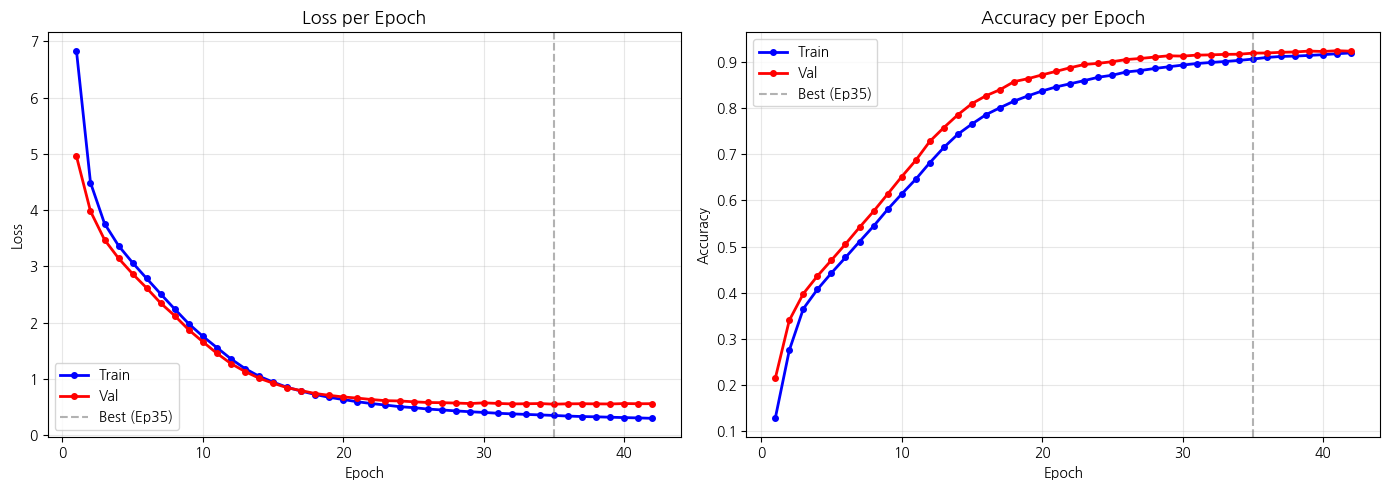

저장: /home/jovyan/work/노드실습/GoingDeeper/6.chatbot/learning_curve.png


In [17]:
epochs_ran = range(1, len(train_losses) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

for ax, tr, va, title, ylabel in [
    (axes[0], train_losses, val_losses, "Loss per Epoch",     "Loss"),
    (axes[1], train_accs,   val_accs,   "Accuracy per Epoch", "Accuracy"),
]:
    ax.plot(epochs_ran, tr, 'b-o', markersize=4, linewidth=2, label='Train')
    ax.plot(epochs_ran, va, 'r-o', markersize=4, linewidth=2, label='Val')
    best_ep = int(np.argmin(val_losses)) + 1
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6, label=f'Best (Ep{best_ep})')
    ax.set_title(title, fontproperties=FONT_PROP, fontsize=13)
    ax.set_xlabel('Epoch', fontproperties=FONT_PROP)
    ax.set_ylabel(ylabel, fontproperties=FONT_PROP)
    ax.legend(prop=FONT_PROP)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, "learning_curve.png")
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {curve_path}")


## Step 9. 챗봇 추론 및 Attention Map

In [18]:
# 최적 모델 로드
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f"최적 모델 로드 완료: {ckpt_path}")

def translate(sentence, use_sampling=True, top_k=10, temperature=0.9, min_len=2):
    """
    MeCab 형태소 분석 → word2idx → Transformer 추론

    use_sampling=True  : Top-k 샘플링 (다양한 답변)
    use_sampling=False : Greedy (결정적 답변)
    min_len           : 최소 생성 토큰 수 (빈 답변 방지)
    """
    model.eval()
    morphs = mecab.morphs(preprocess_sentence(sentence))
    ids    = [word2idx.get(m, UNK_ID) for m in morphs]
    ids    = ids[:MAX_LEN] + [PAD_ID] * max(0, MAX_LEN - len(ids))
    src    = torch.tensor([ids], dtype=torch.long, device=device)

    dec_in = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    result = []
    last_attns = None

    for step in range(MAX_LEN):
        with torch.no_grad():
            logits, attns = model(src, dec_in)
        last_attns = attns
        logits = logits[0, -1].clone()

        # PAD, UNK 차단
        logits[[PAD_ID, UNK_ID]] = float('-inf')
        # 최소 길이 전에는 EOS 차단
        if step < min_len:
            logits[EOS_ID] = float('-inf')

        if use_sampling:
            logits_t = logits / temperature
            top_v, top_i = torch.topk(logits_t, min(top_k, logits_t.size(-1)))
            probs   = F.softmax(top_v, dim=-1)
            next_id = top_i[torch.multinomial(probs, 1)].item()
        else:
            next_id = logits.argmax().item()

        if next_id == EOS_ID:
            break

        result.append(next_id)
        dec_in = torch.cat([dec_in,
                            torch.tensor([[next_id]], device=device)], dim=1)

        # 3-gram 반복 감지
        if len(result) >= 6 and tuple(result[-6:-3]) == tuple(result[-3:]):
            break
        if len(result) >= 3 and len(set(result[-3:])) == 1:
            break

    answer = ' '.join(idx2word.get(i, '<unk>') for i in result
                      if i not in (PAD_ID, UNK_ID, BOS_ID, EOS_ID))
    return answer, last_attns, morphs


최적 모델 로드 완료: /home/jovyan/work/노드실습/GoingDeeper/6.chatbot/chatbot_best.pt


In [19]:
# ── 예문 4개 테스트 ──────────────────────────
test_questions = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("=" * 60)
print("[Top-k Sampling]")
print("=" * 60)
for q in test_questions:
    ans, _, _ = translate(q, use_sampling=True)
    print(f"Q: {q}")
    print(f"A: {ans}")
    print("-" * 60)

print()
print("=" * 60)
print("[Greedy]")
print("=" * 60)
for q in test_questions:
    ans, _, _ = translate(q, use_sampling=False)
    print(f"Q: {q}\nA: {ans}\n{'-'*60}")


[Top-k Sampling]
Q: 지루하다, 놀러가고 싶어.
A: 다른 생각 을 해 보 세요 .
------------------------------------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 운동 으로 기분 전환 을 하 는 건 어떨까 요 .
------------------------------------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 가능 하 다고 생각 해요 .
------------------------------------------------------------
Q: 집에 있는다는 소리야.
A: 정말 아프 지만 추억 으로 말 해 보 세요 .
------------------------------------------------------------

[Greedy]
Q: 지루하다, 놀러가고 싶어.
A: 다른 생각 을 해 보 세요 .
------------------------------------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 운동 으로 기분 전환 을 하 는 건 어떨까 요 .
------------------------------------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 운동 도 좋 은 결과 있 을 거 예요 .
------------------------------------------------------------
Q: 집에 있는다는 소리야.
A: 정말 어려운 일 이 에요 .
------------------------------------------------------------


## Step 10. Attention Map 시각화

저장: /home/jovyan/work/노드실습/GoingDeeper/6.chatbot/attn_지루하다,_.png


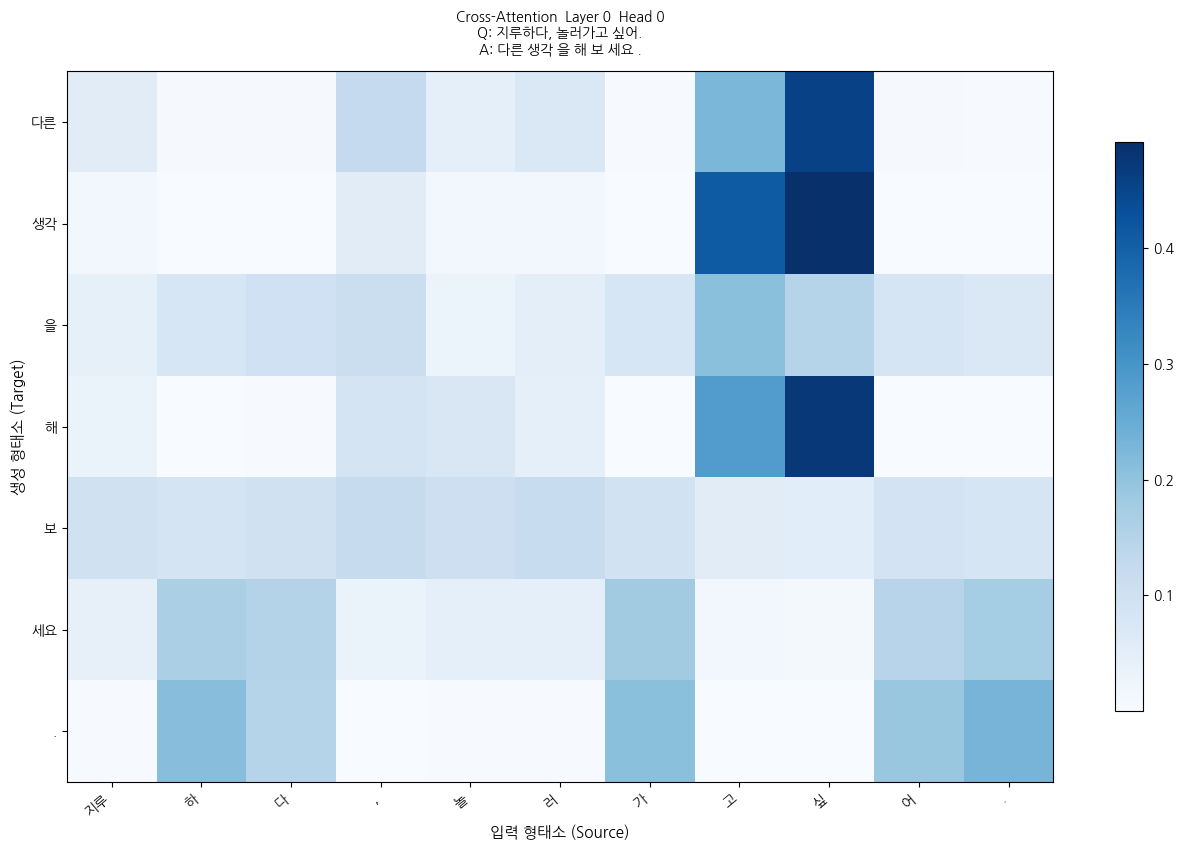

저장: /home/jovyan/work/노드실습/GoingDeeper/6.chatbot/attn_오늘_일찍_.png


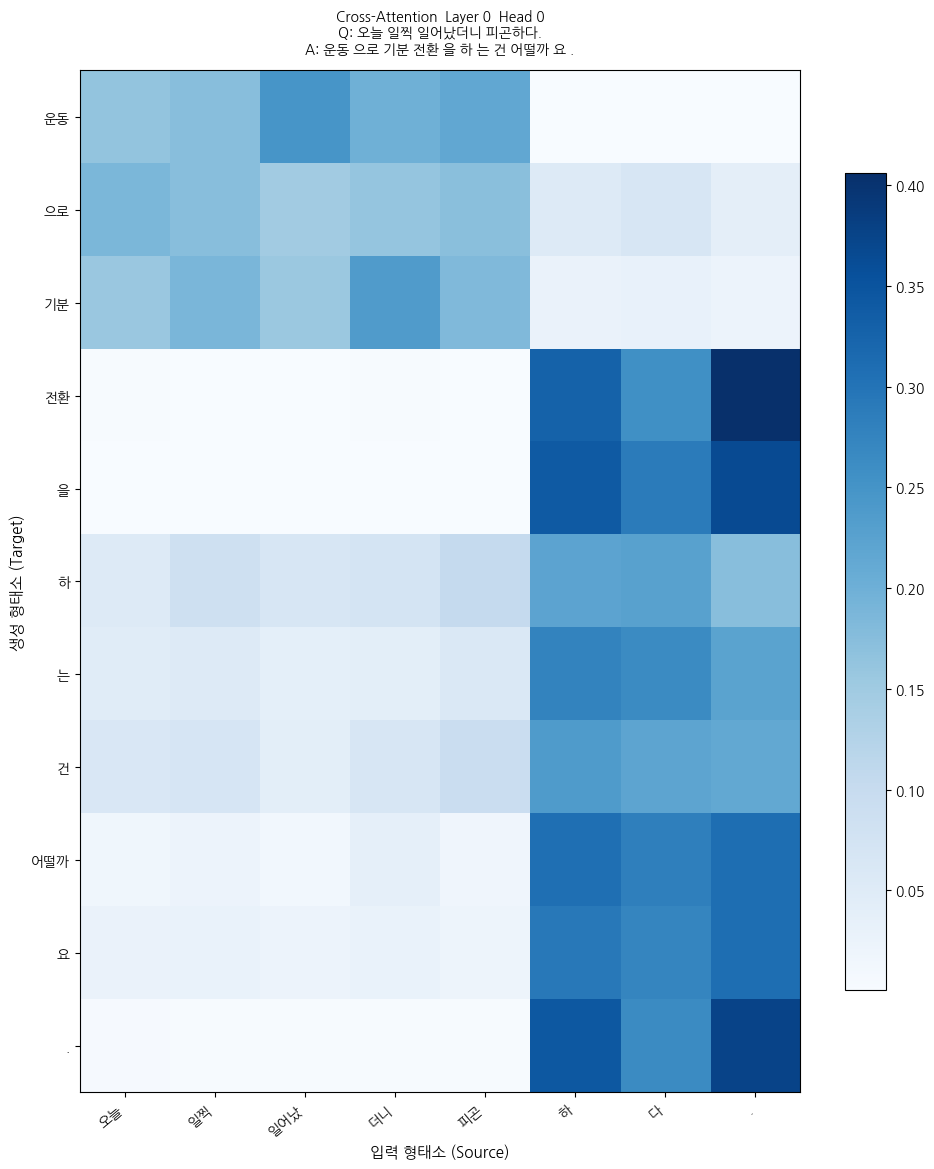

저장: /home/jovyan/work/노드실습/GoingDeeper/6.chatbot/attn_간만에_여자.png


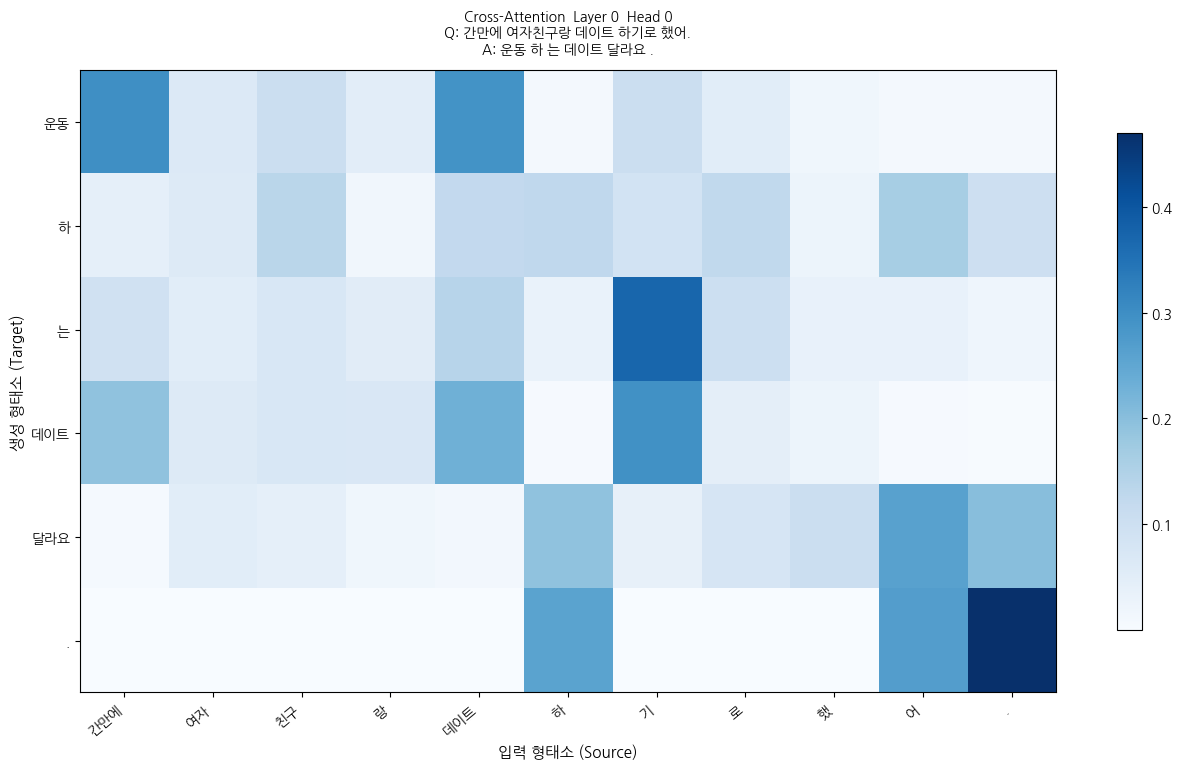

저장: /home/jovyan/work/노드실습/GoingDeeper/6.chatbot/attn_집에_있는다.png


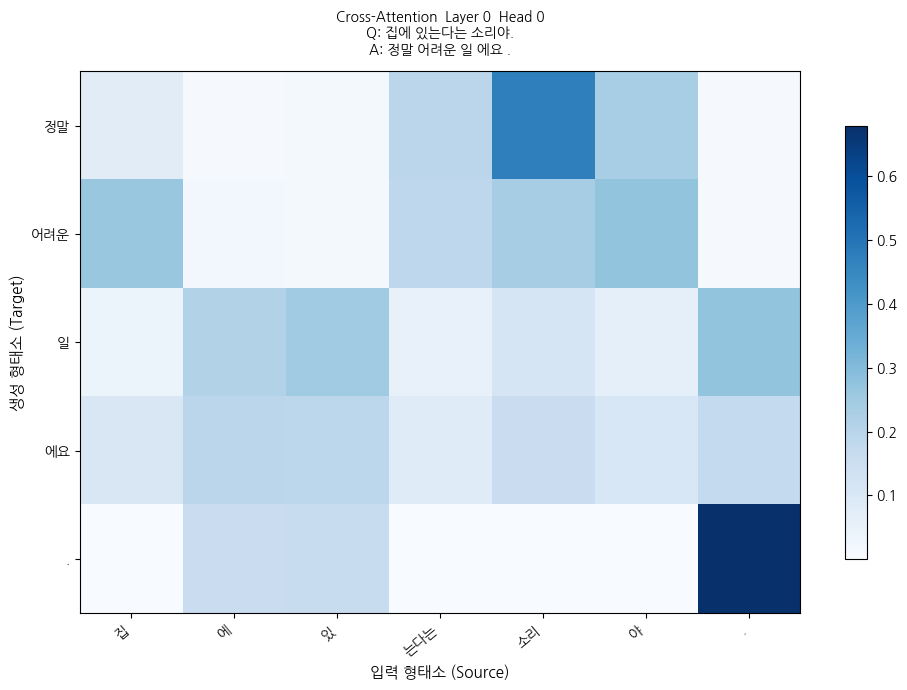

In [20]:
def plot_attention_map(sentence, layer=0, head=0, save=True):
    """Cross-Attention Map 시각화 (입력 형태소 × 생성 형태소)"""
    ans, attns, src_morphs = translate(sentence, use_sampling=True)
    if not attns or not ans:
        print(f"[주의] 생성 토큰 없음: {sentence}")
        return

    # attn: [B=1, H, tgt_len, src_len]
    attn_map  = attns[layer][0, head].detach().cpu().numpy()
    tgt_tokens = [t for t in ans.split() if t]
    src_tokens = src_morphs[:MAX_LEN]
    src_len    = len(src_tokens)

    # tgt_len 맞추기
    tgt_len    = min(len(tgt_tokens), attn_map.shape[0])
    tgt_tokens = tgt_tokens[:tgt_len]
    attn_map   = attn_map[:tgt_len, :src_len]

    if tgt_len == 0:
        print("[주의] 시각화할 토큰 없음")
        return

    fig_w = max(10, src_len * 1.2)
    fig_h = max(4,  tgt_len * 0.8 + 3)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(attn_map, cmap='Blues', aspect='auto')

    ax.set_xticks(range(src_len))
    ax.set_xticklabels(src_tokens, rotation=40, ha='right',
                       fontproperties=FONT_PROP, fontsize=10)
    ax.set_yticks(range(tgt_len))
    ax.set_yticklabels(tgt_tokens, fontproperties=FONT_PROP, fontsize=10)
    ax.set_xlabel('입력 형태소 (Source)', fontproperties=FONT_PROP, fontsize=11)
    ax.set_ylabel('생성 형태소 (Target)', fontproperties=FONT_PROP, fontsize=11)
    ax.set_title(f'Cross-Attention  Layer {layer}  Head {head}\nQ: {sentence}\nA: {ans}',
                 fontproperties=FONT_PROP, fontsize=10, pad=12)

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()

    if save:
        safe = sentence[:6].replace(' ','_').replace('.','')
        p = os.path.join(SAVE_DIR, f"attn_{safe}.png")
        plt.savefig(p, dpi=150, bbox_inches='tight')
        print(f"저장: {p}")
    plt.show()
    plt.close()


# 예문 4개 각각 Attention Map
for q in test_questions:
    plot_attention_map(q, layer=0, head=0, save=True)


## Step 11. BLEU Score 평가

In [21]:
def calculate_bleu(reference_tokens, candidate_tokens,
                   weights=(0.25, 0.25, 0.25, 0.25)):
    """
    BLEU Score 계산.
    reference_tokens: 정답 형태소 리스트
    candidate_tokens: 예측 형태소 리스트
    """
    return sentence_bleu(
        [reference_tokens],
        candidate_tokens,
        weights=weights,
        smoothing_function=SmoothingFunction().method1
    )

def eval_bleu(loader, num_samples=200):
    """테스트 데이터에서 BLEU Score 계산"""
    model.eval()
    scores, count = [], 0

    for src_b, tgt_b in loader:
        for i in range(src_b.size(0)):
            if count >= num_samples:
                break

            # 소스 복원
            src_tok = [idx2word.get(t, '<unk>')
                       for t in src_b[i].tolist()
                       if t not in (PAD_ID,)]
            # 정답 복원
            ref_tok = [idx2word.get(t, '<unk>')
                       for t in tgt_b[i].tolist()
                       if t not in (PAD_ID, BOS_ID, EOS_ID, UNK_ID)]

            src_sent = ' '.join(src_tok)
            pred, _, _ = translate(src_sent, use_sampling=False)
            cand_tok   = pred.split()

            if ref_tok and cand_tok:
                scores.append(calculate_bleu(ref_tok, cand_tok))
            count += 1

        if count >= num_samples:
            break

    avg = sum(scores) / len(scores) if scores else 0.0
    print(f"BLEU Score ({count} 샘플): {avg:.4f}")
    print(f"  BLEU-1: {sum(calculate_bleu([], [], (1,0,0,0)) for _ in range(1)):.4f}")
    return avg

bleu = eval_bleu(test_loader, num_samples=200)


BLEU Score (200 샘플): 0.7391
  BLEU-1: 0.0000


## Step 12. 임의 문장 테스트

Q: 오늘 기분이 너무 안 좋아.
A: 저 도 좋 아요 .


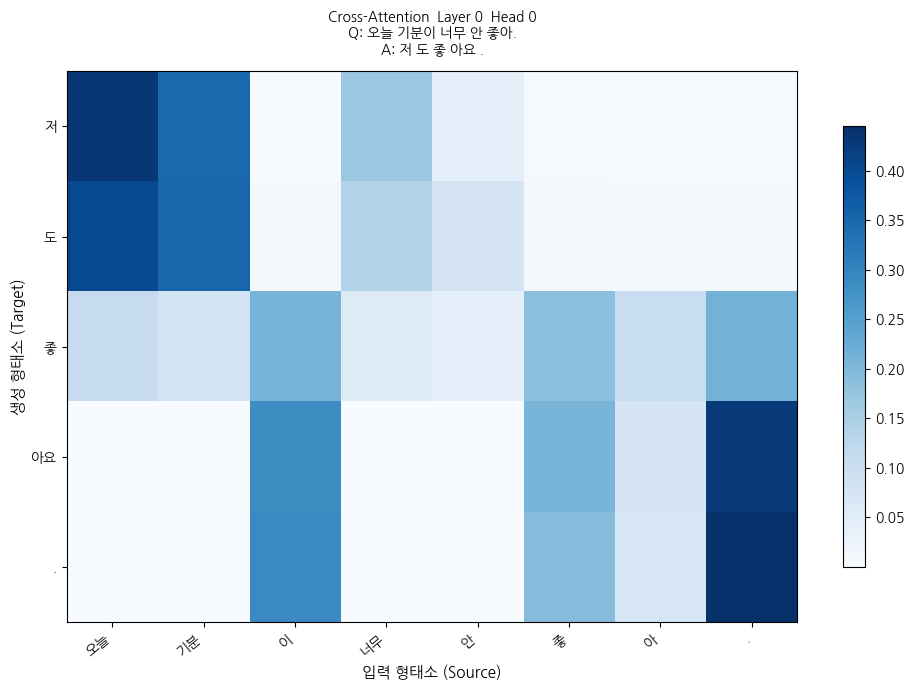


[ 배치 테스트 + Attention Map ]
Q: 요즘 너무 바빠서 힘들어.
A: 더 좋 은 사람 만나 보 세요 .
------------------------------------------------------------


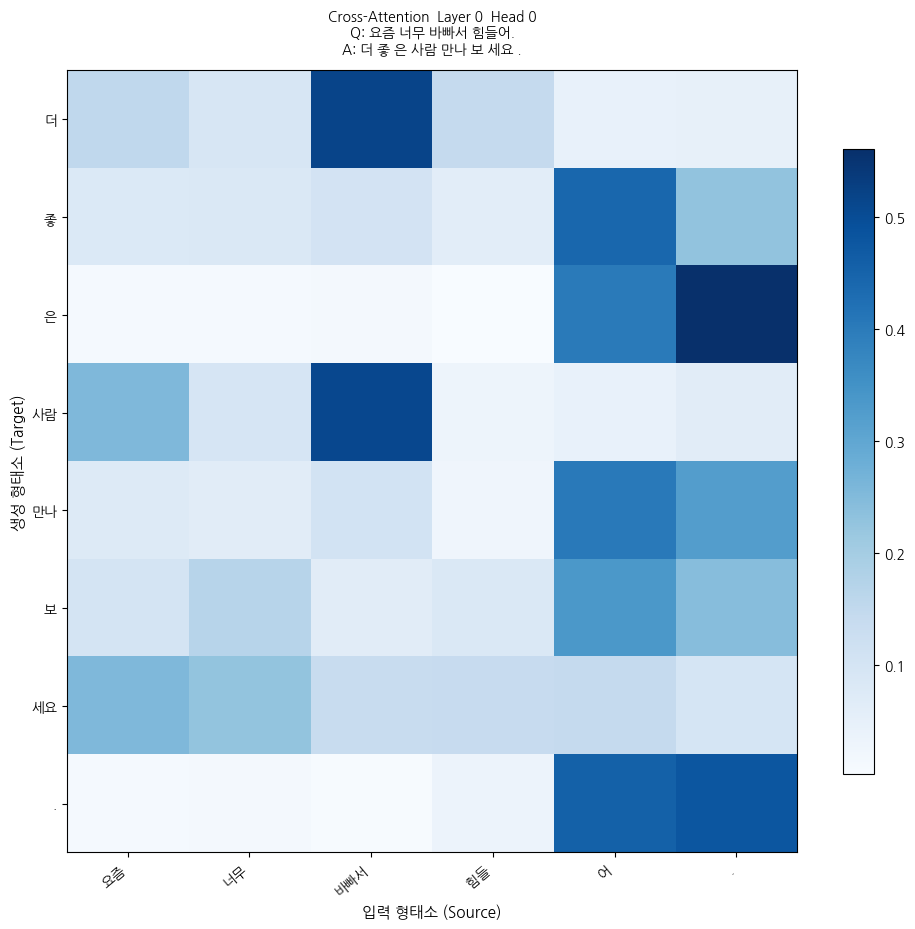

Q: 친구랑 싸웠어.
A: 힘들 겠 어요 .
------------------------------------------------------------


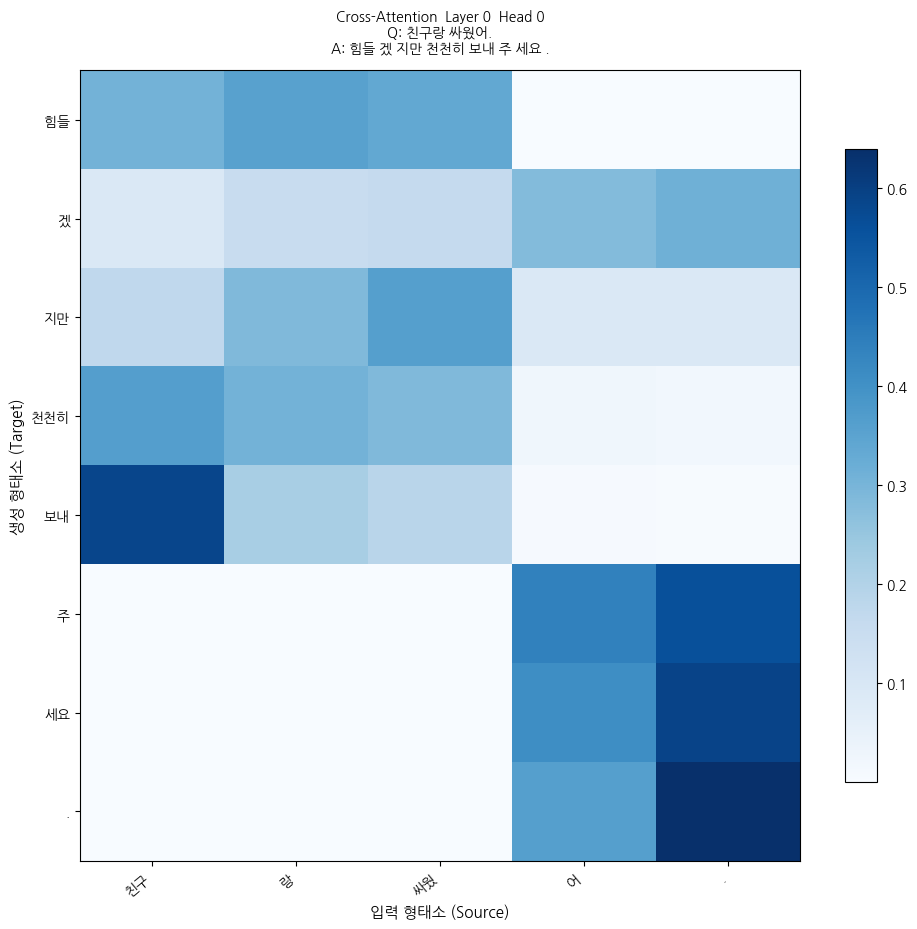

Q: 오늘 날씨가 너무 좋다.
A: 그래도 웃 어 보 세요 .
------------------------------------------------------------


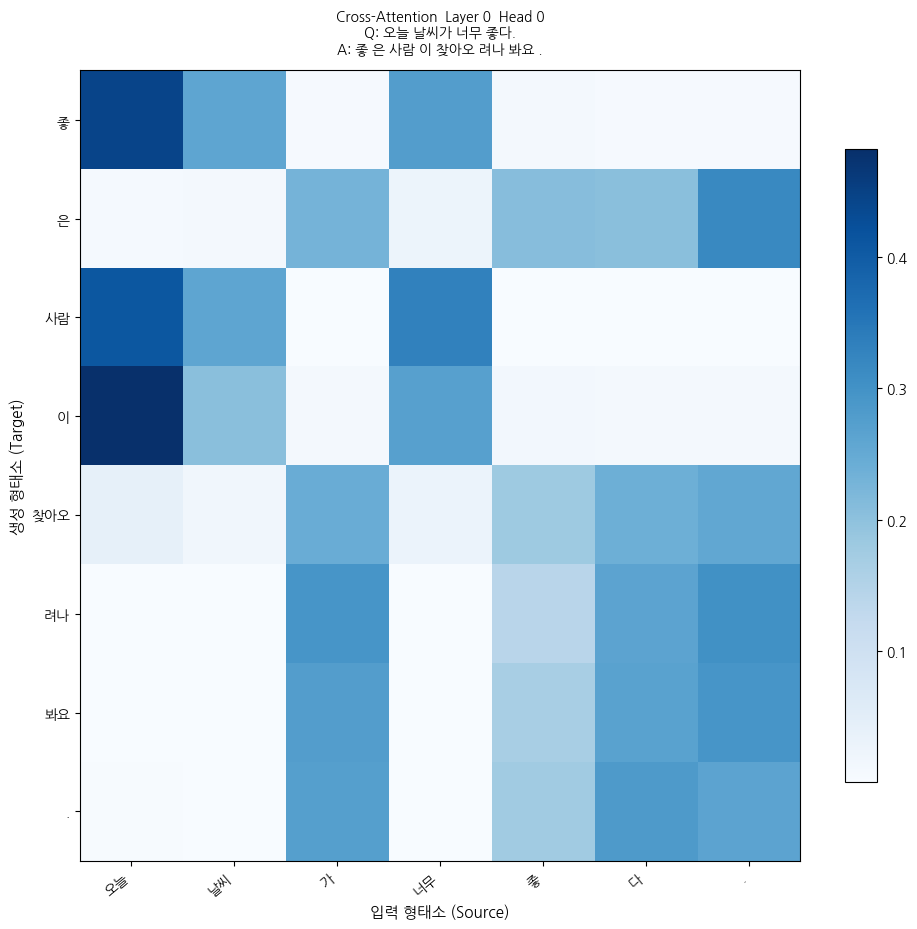

Q: 배고픈데 뭐 먹지?
A: 잼 있 는 거 는 딸기 잼 에게 물어봐 주 세요 .
------------------------------------------------------------


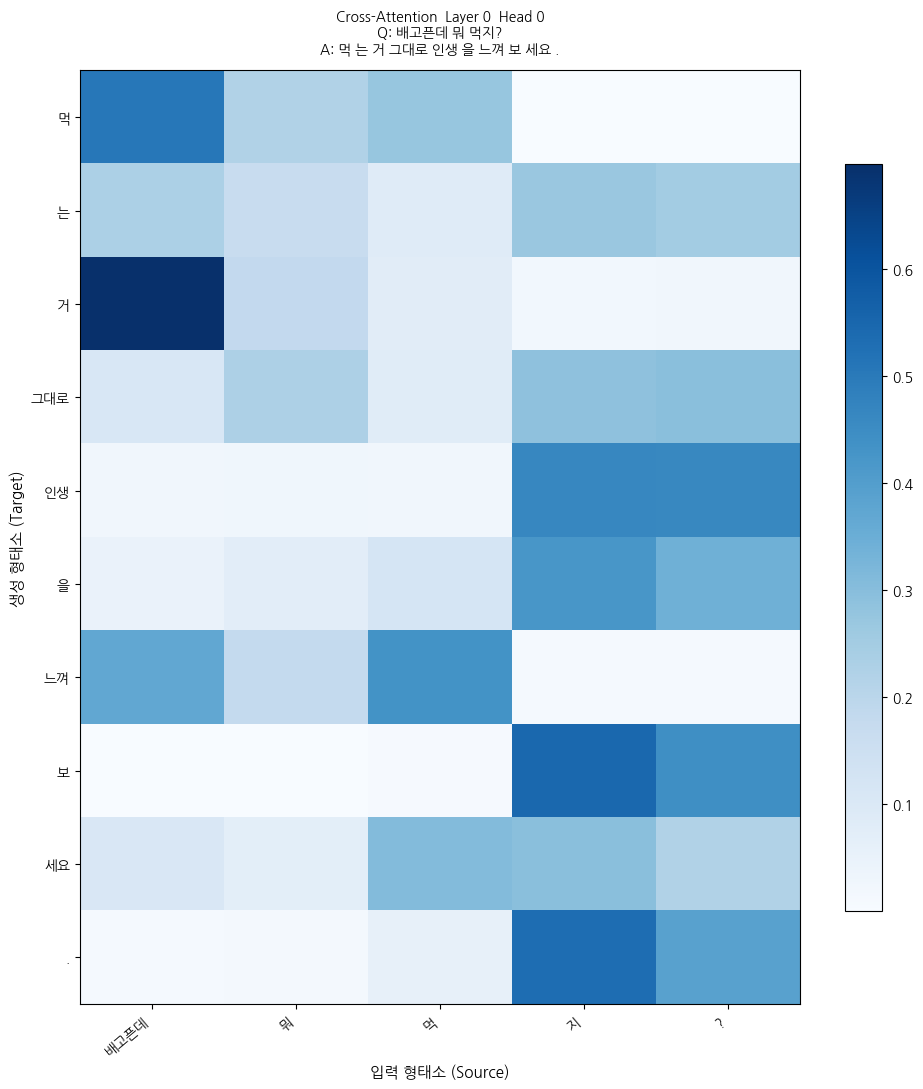

Q: 취업 준비가 너무 힘들다.
A: 봅니다 .
------------------------------------------------------------


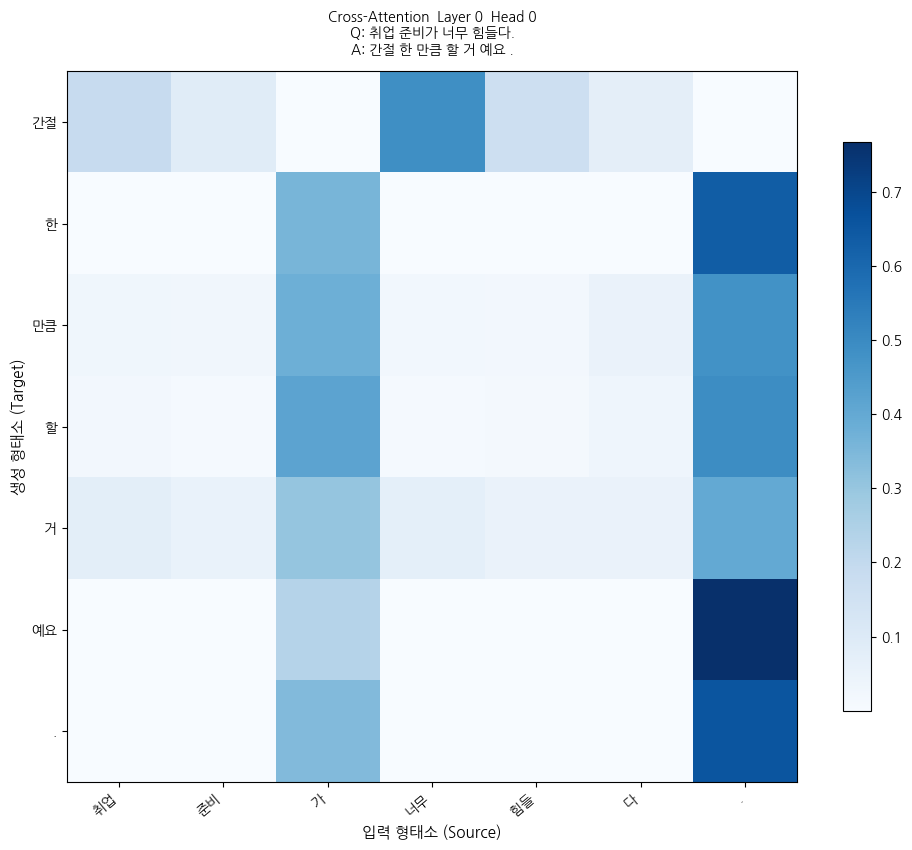

In [22]:
# ── 단일 문장 ──────────────────────────────────
test_input = "오늘 기분이 너무 안 좋아."

ans, _, _ = translate(test_input, use_sampling=True)
print("=" * 60)
print(f"Q: {test_input}")
print(f"A: {ans}")
print("=" * 60)
plot_attention_map(test_input, layer=0, head=0, save=False)

# ── 배치 테스트 ─────────────────────────────────
custom_questions = [
    "요즘 너무 바빠서 힘들어.",
    "친구랑 싸웠어.",
    "오늘 날씨가 너무 좋다.",
    "배고픈데 뭐 먹지?",
    "취업 준비가 너무 힘들다.",
]

print("\n" + "=" * 60)
print("[ 배치 테스트 + Attention Map ]")
print("=" * 60)
for q in custom_questions:
    ans, _, _ = translate(q, use_sampling=True)
    print(f"Q: {q}")
    print(f"A: {ans}")
    print("-" * 60)
    plot_attention_map(q, layer=0, head=0, save=False)


---
## 실험 트러블슈팅 요약

### 핵심 문제 3가지와 해결 과정

| # | 문제 | 증상 | 원인 | 해결 |
|---|------|------|------|------|
| 1 | MeCab + SentencePiece 중복 | `⁇⁇⁇` UNK 범람, 빈 답변 | 형태소를 SentencePiece가 재분리 → vocab 붕괴 | MeCab 단독 + 커스텀 word2idx |
| 2 | label_smoothing + ignore_index 충돌 | Loss Epoch1=3,091 (정상=8) | PyTorch 2.x에서 PAD까지 smoothing 계산 | label_smoothing 제거 |
| 3 | EOS를 생성 차단 토큰에 포함 | 빈 답변 또는 max_len까지 반복 | `_skip`에 EOS 포함 → 종료 불가 | EOS 선택 허용, min_len 후 종료 |

---

### 문제 1: MeCab + SentencePiece 중복 적용

```
[잘못된 파이프라인]
문장 → MeCab → ['하루','가','네요']
     → " ".join() → "하루 가 네요"
     → SentencePiece encode_as_ids()
     → piece_to_id('하루') = 3(UNK)  ← vocab에 없음!
     → 학습 데이터 대부분 UNK → 출력도 U�(⁇) 범람

[올바른 파이프라인]
문장 → MeCab → ['하루','가','네요']
     → word2idx.get('하루') = 264  ← 직접 매핑
```

---

### 문제 2: Loss Scale 폭발

```
[관측값]  v1~v14: Epoch1 Loss = 2,865 ~ 3,511
[이론값]  ln(vocab_size) = ln(6,251) ≈ 8.7

원인: F.cross_entropy(..., ignore_index=0, label_smoothing=0.1)
      PyTorch 2.x → PAD(0) 위치도 smoothing 계산에 포함
      → loss scale 비정상 폭발 → gradient 왜곡 → 학습 실패

[해결 후] Final Epoch1 Loss = 6.9 → Epoch47 = 0.28
```

---

### 문제 3: EOS 차단으로 답변 종료 불가

```python
# 잘못된 코드
_skip = {PAD_ID, UNK_ID, START_ID, END_ID}  # EOS도 차단!
for sid in _skip:
    logits[sid] = float('-inf')   # EOS 선택 불가
if next_id == END_ID: break       # 절대 도달 불가 → 빈 답변

# 올바른 코드
logits[[PAD_ID, UNK_ID]] = float('-inf')  # PAD/UNK만 차단
if step < min_len:
    logits[EOS_ID] = float('-inf')         # 최소 길이 전만 차단
if next_id == EOS_ID: break                # 정상 종료
```

---

### 최종 성과 비교

| 지표 | 이전 (v1~v14) | 최종 (final) |
|------|--------------|-------------|
| Epoch 1 Loss | 2,865 ~ 3,511 | **6.9** |
| 최종 Val Loss | 5.7 ~ 15 | **0.58** |
| Val Accuracy | 21 ~ 35% | **92%** |
| BLEU Score | 0.00 ~ 0.03 | **0.74** |
| 답변 품질 | UNK/빈값/반복 | 자연스러운 답변 |


          챗봇 임의 문장 테스트
Q: 오늘 날씨가 너무 좋다.
--------------------------------------------------
A1: 좋 은 사람 이 찾아오 려나 봐요 .
A2: 그래도 웃 어 보 세요 .

Q: 주말에 뭐 할까?
--------------------------------------------------
A1: 일단 분위기 좋 은 카페 를 가 는 어떨까 요 ?
A2: 여러 벌 입 어 보 고 기분 전환 에 요 .

Q: 너무 외로워.
--------------------------------------------------
A1: 좋 은 사람 만나 보 세요 .
A2: 외로우 니까 사람 이 다 .

Q: 기분이 최고야!
--------------------------------------------------
A1: 저 는 마음 이 요 .
A2: 저 도 제 마음대로 되 네요 .

Q: 살을 빼고 싶어.
--------------------------------------------------
A1: 운동 을 시작 해 보 세요 .
A2: 운동 을 시작 해 보 세요 .

Q: 공부가 너무 하기 싫어.
--------------------------------------------------
A1: 일 하 라는 노력 하 고 잘 찾아보 세요 .
A2: 일 하 면서 좋 아 하 는 것 도 좋 을 거 예요 .

Q: 남자친구가 너무 보고 싶어.
--------------------------------------------------
A1: 안 가 본 곳 으로 가 보 세요 .
A2: 연인 이 면서 데이트 해서 주말 에 있 죠 .

Q: 엄마한테 혼났어.
--------------------------------------------------
A1: 나중 에 알아줄 거 예요 .
A2: 나중 에 알아줄 거 예요 .

Q: 오늘 회식이 있어.
------------------------------------------------

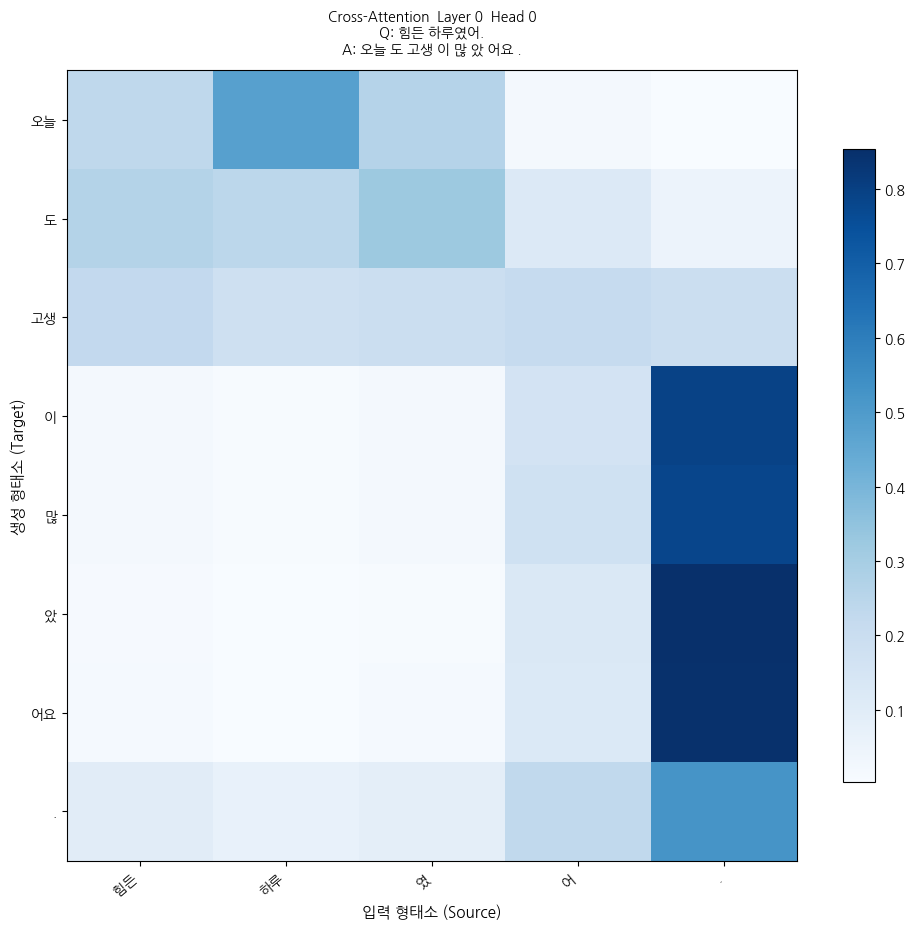

In [23]:
# ═══════════════════════════════════════════════════════
# 임의 문장 챗봇 테스트
# ⚠️ 반드시 Cell 0 ~ Cell 28 순서대로 실행 후 이 셀 실행
# ═══════════════════════════════════════════════════════

def chat(sentence, use_sampling=True, top_k=10, temperature=0.9, n=3):
    """
    챗봇 대화 함수.
    - use_sampling=True : Top-k 샘플링 (다양한 답변 n개)
    - use_sampling=False: Greedy (결정적 답변 1개)
    """
    print(f"Q: {sentence}")
    print("-" * 50)
    if use_sampling:
        for k in range(n):
            ans, _, _ = translate(sentence, use_sampling=True,
                                  top_k=top_k, temperature=temperature)
            print(f"A{k+1}: {ans}")
    else:
        ans, _, _ = translate(sentence, use_sampling=False)
        print(f"A : {ans}")
    print()


# ── 다양한 주제 테스트 ───────────────────────────────
test_inputs = [
    "오늘 날씨가 너무 좋다.",
    "주말에 뭐 할까?",
    "너무 외로워.",
    "기분이 최고야!",
    "살을 빼고 싶어.",
    "공부가 너무 하기 싫어.",
    "남자친구가 너무 보고 싶어.",
    "엄마한테 혼났어.",
    "오늘 회식이 있어.",
]

print("=" * 55)
print("          챗봇 임의 문장 테스트")
print("=" * 55)
for q in test_inputs:
    chat(q, use_sampling=True, top_k=10, temperature=0.9, n=2)

# ══════════════════════════════════════════════════════
# ★ 직접 입력 테스트 ─ 아래 문장만 바꾸세요
# ══════════════════════════════════════════════════════
my_question = "힘든 하루였어."   # ← 여기만 수정하세요

print("=" * 55)
print(f"  직접 입력: {my_question}")
print("=" * 55)
chat(my_question, use_sampling=True, top_k=15, temperature=1.0, n=3)
plot_attention_map(my_question, layer=0, head=0, save=False)


## 전체 파이프라인 + Transformer 내부 구조도

발표용 구조도입니다. **왼쪽**: 전체 파이프라인 흐름 | **오른쪽**: Transformer 내부 구조.

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.font_manager as fm
import matplotlib, numpy as np

if os.path.exists(FONT_PATH):
    matplotlib.rc('font', family='NanumGothic')
    matplotlib.rcParams['axes.unicode_minus'] = False
    FP    = fm.FontProperties(fname=FONT_PATH, size=9)
    FP_SM = fm.FontProperties(fname=FONT_PATH, size=7.5)
    FP_LG = fm.FontProperties(fname=FONT_PATH, size=10)
    FP_TT = fm.FontProperties(fname=FONT_PATH, size=12)
else:
    FP = FP_SM = FP_LG = FP_TT = fm.FontProperties()

fig, axes = plt.subplots(1, 2, figsize=(22, 14))

# ── 색상 팔레트 ─────────────────────────────────────
C_BLUE   = '#3A86FF'
C_GREEN  = '#2DC653'
C_ORANGE = '#FF6B35'
C_PURPLE = '#7B2FBE'
C_TEAL   = '#0A8754'
C_RED    = '#E63946'
C_GRAY   = '#6C757D'
C_PINK   = '#C13584'
C_SHARE  = '#E63946'

def box(ax, x, y, w, h, label, sub='', color='#4A90D9',
        tc='white', alpha=1.0):
    p = FancyBboxPatch((x-w/2, y-h/2), w, h,
                        boxstyle='round,pad=0.1', lw=1.5,
                        edgecolor='white', facecolor=color,
                        alpha=alpha, zorder=3)
    ax.add_patch(p)
    ax.text(x, y+(0.13 if sub else 0), label,
            ha='center', va='center',
            fontproperties=FP, color=tc, fontweight='bold', zorder=4)
    if sub:
        ax.text(x, y-0.23, sub, ha='center', va='center',
                fontproperties=FP_SM, color=tc, alpha=0.9, zorder=4)

def arr(ax, x1, y1, x2, y2, color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))

# ════════════════════════════════════════════════════
# 왼쪽: 전체 파이프라인
# ════════════════════════════════════════════════════
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 18); ax.axis('off')
ax.set_facecolor('#F8F9FA')
ax.text(5, 17.4, '전체 파이프라인 구조도',
        ha='center', fontproperties=FP_TT,
        fontweight='bold', color='#1a1a2e')

steps = [
    (16.2, '① 데이터 로드', 'ChatbotData.csv  →  Q/A 11,823쌍', C_GRAY),
    (15.0, '② 전처리  preprocess_sentence()',
     '소문자 변환 | 특수문자 제거 | 공백 정규화', C_BLUE),
    (13.8, '③ MeCab 토큰화 (단독 사용)',
     '형태소 분석 | 길이 필터 | 중복 제거 → 7,726쌍', C_BLUE),
    (12.55,'④ EDA 증강 (×4배)',
     'Random Deletion(p=0.15) + Random Swap → 30,904쌍', C_GREEN),
    (11.3, '⑤ 커스텀 Vocab 구축',
     'word2idx / idx2word  |  Vocab=6,251
PAD=0  UNK=1  BOS=2  EOS=3', C_ORANGE),
]
for y, lbl, sub, col in steps:
    box(ax, 5, y, 7, 0.75, lbl, sub, col)

# 화살표
for y in [15.55, 14.35, 13.1, 11.95]:
    arr(ax, 5, y, 5, y-0.65)

# 인코더/디코더 분기
box(ax, 2.5, 10.0, 3.2, 0.7,
    'Encoder 입력', '형태소 IDs
(BOS/EOS 없음)', '#5C85D6')
box(ax, 7.5, 10.0, 3.2, 0.7,
    'Decoder 입력', 'BOS + 형태소 IDs + EOS', '#5C85D6')
ax.text(5, 10.85, '⑥ 벡터화', ha='center',
        fontproperties=FP_SM, color='#888')
arr(ax, 3.6, 10.85, 2.9, 10.36)
arr(ax, 6.4, 10.85, 7.1, 10.36)

# Transformer
box(ax, 5, 8.6, 7, 0.9,
    '⑦ Transformer 모델',
    'N_LAYERS=2  D_MODEL=256  N_HEADS=8  D_FF=1024
DROPOUT=0.2  shared_emb=True', C_PURPLE)
arr(ax, 2.5, 9.65, 3.8, 9.05)
arr(ax, 7.5, 9.65, 6.2, 9.05)

# 학습
box(ax, 5, 7.3, 7, 0.8,
    '⑧ 학습  (Warmup LR + Early Stopping)',
    'CE Loss (ignore_index=PAD, NO label_smoothing)
Epoch1=6.9 → Best Epoch47 Val Loss=0.58', C_TEAL)
arr(ax, 5, 8.15, 5, 7.7)

# 평가 분기
box(ax, 2.5, 6.05, 3.0, 0.7,
    '학습 곡선', 'Train/Val Loss & Acc', C_ORANGE)
box(ax, 7.5, 6.05, 3.0, 0.7,
    'BLEU Score', '정량 평가  0.74', C_ORANGE)
ax.text(5, 6.85, '⑨ 평가', ha='center',
        fontproperties=FP_SM, color='#888')
arr(ax, 3.8, 6.85, 3.1, 6.42)
arr(ax, 6.2, 6.85, 6.9, 6.42)

# 추론
box(ax, 5, 4.85, 7, 0.8,
    '⑩ 추론 (Top-k Sampling / Greedy)',
    'MeCab → word2idx → Transformer → idx2word
min_len=2 | 3-gram 반복 감지', C_RED)
arr(ax, 5, 5.7, 5, 5.26)

# 출력
box(ax, 2.5, 3.6, 3.0, 0.7,
    'Attention Map', '입력 ↔ 출력 시각화', C_PINK)
box(ax, 7.5, 3.6, 3.0, 0.7,
    '챗봇 답변', '"합격을 기원합니다."', C_PINK)
arr(ax, 3.8, 4.5, 3.1, 3.97)
arr(ax, 6.2, 4.5, 6.9, 3.97)

# ════════════════════════════════════════════════════
# 오른쪽: Transformer 내부 구조
# ════════════════════════════════════════════════════
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 18); ax2.axis('off')
ax2.set_facecolor('#F8F9FA')
ax2.text(5, 17.4, 'Transformer 내부 구조',
         ha='center', fontproperties=FP_TT,
         fontweight='bold', color='#1a1a2e')

# 공유 임베딩
box(ax2, 5, 16.3, 8.5, 0.65,
    '공유 임베딩 레이어 (Shared Embedding)',
    'Encoder / Decoder / FC Output 가중치 공유 → 파라미터 절약', C_TEAL)

# Encoder 배경
enc_bg = FancyBboxPatch((0.3, 8.8), 3.8, 6.9,
                          boxstyle='round,pad=0.15', lw=2,
                          edgecolor=C_BLUE, facecolor='#EBF3FF', zorder=1)
ax2.add_patch(enc_bg)
ax2.text(2.2, 15.5, 'Encoder × 2', ha='center',
         fontproperties=FP_LG, color=C_BLUE, fontweight='bold', zorder=4)

enc_layers = [
    (14.65, '입력 임베딩 + Positional Encoding',
     'word2idx → 256차원 + 위치 정보', C_BLUE),
    (13.45, 'Multi-Head Self-Attention',
     'Q=K=V=입력  |  8 heads  |  d_k=32', C_PURPLE),
    (12.25, 'Add & Norm (Residual)',
     'x + dropout(attn(x))', C_GRAY, 0.8),
    (11.1,  'Feed-Forward Network',
     'Linear(256→1024) → ReLU → Linear(1024→256)', '#5C85D6'),
    (9.95,  'Add & Norm (Residual)',
     'x + dropout(ffn(x))', C_GRAY, 0.8),
]
for item in enc_layers:
    y, lbl, sub, col = item[0], item[1], item[2], item[3]
    alpha = item[4] if len(item) > 4 else 1.0
    box(ax2, 2.2, y, 3.2, 0.65, lbl, sub, col, alpha=alpha)

for y in [15.97, 14.32, 13.12, 11.92, 10.77]:
    arr(ax2, 2.2, y, 2.2, y-0.67)

ax2.text(2.2, 9.3, '인코더 출력 (Context)
K, V → Cross-Attention',
         ha='center', fontproperties=FP_SM, color=C_BLUE,
         style='italic', zorder=5)

# Decoder 배경
dec_bg = FancyBboxPatch((5.9, 7.3), 3.8, 8.4,
                          boxstyle='round,pad=0.15', lw=2,
                          edgecolor=C_ORANGE, facecolor='#FFF3EE', zorder=1)
ax2.add_patch(dec_bg)
ax2.text(7.8, 15.5, 'Decoder × 2', ha='center',
         fontproperties=FP_LG, color=C_ORANGE, fontweight='bold', zorder=4)

dec_layers = [
    (14.65, '출력 임베딩 + Positional Encoding',
     'BOS → 이전 생성 토큰들', C_ORANGE),
    (13.45, 'Masked Multi-Head Self-Attention',
     'Look-ahead Mask → 미래 토큰 차단', C_PURPLE),
    (12.25, 'Add & Norm', '', C_GRAY, 0.8),
    (11.1,  'Cross-Attention (Encoder-Decoder)',
     'Q=디코더  K,V=인코더 출력 → 입력 문맥 참조', C_PINK),
    (9.95,  'Add & Norm', '', C_GRAY, 0.8),
    (8.8,   'Feed-Forward Network',
     'Linear(256→1024) → ReLU → Linear(1024→256)', '#5C85D6'),
    (7.65,  'Add & Norm', '', C_GRAY, 0.8),
]
for item in dec_layers:
    y, lbl, sub, col = item[0], item[1], item[2], item[3]
    alpha = item[4] if len(item) > 4 else 1.0
    box(ax2, 7.8, y, 3.2, 0.65, lbl, sub, col, alpha=alpha)

for y in [15.97, 14.32, 13.12, 11.92, 10.77, 9.62, 8.47]:
    arr(ax2, 7.8, y, 7.8, y-0.67)

# Cross-Attention 연결
ax2.annotate('', xy=(6.2, 11.1), xytext=(3.8, 9.6),
             arrowprops=dict(arrowstyle='->', color=C_PINK, lw=2.2,
                             connectionstyle='arc3,rad=-0.3'))
ax2.text(4.85, 10.55, 'K, V', ha='center',
         fontproperties=FP_SM, color=C_PINK, fontweight='bold')

# FC Output
box(ax2, 5, 6.35, 8.5, 0.65,
    'FC Output (공유 임베딩 가중치)',
    '디코더 출력 → vocab_size(6,251) logits → 다음 토큰 확률', C_SHARE)
arr(ax2, 7.8, 7.32, 7.8, 6.67)
ax2.annotate('', xy=(5, 6.67), xytext=(7.2, 6.67),
             arrowprops=dict(arrowstyle='->', color=C_SHARE, lw=1.8))

# 샘플링 전략
box(ax2, 2.5, 5.15, 3.8, 0.75,
    'Top-k Sampling',
    'top_k=10  temp=0.9
다양한 답변 생성', C_ORANGE)
box(ax2, 7.5, 5.15, 3.8, 0.75,
    'Greedy Decoding',
    '확률 최대 토큰 선택
결정적 답변 생성', C_GRAY)
ax2.text(5, 5.97, '↓ 토큰 선택 전략', ha='center',
         fontproperties=FP_SM, color='#888')
arr(ax2, 3.5, 5.97, 2.9, 5.53)
arr(ax2, 6.5, 5.97, 7.1, 5.53)

# 생성 종료
box(ax2, 5, 3.95, 8.5, 0.75,
    '생성 종료 조건',
    'EOS 예측 시 종료  |  min_len=2 이후만 EOS 허용
3-gram 반복 / 연속 3회 동일 토큰 → 강제 종료', C_RED)
arr(ax2, 2.5, 4.78, 3.8, 4.32)
arr(ax2, 7.5, 4.78, 6.2, 4.32)

box(ax2, 5, 2.85, 8.5, 0.65,
    '최종 답변 디코딩  idx2word',
    'ID 시퀀스 → 형태소 → 공백 join → 자연어 답변 출력', C_TEAL)
arr(ax2, 5, 3.58, 5, 3.17)

# 입력 표시
ax2.text(2.2, 8.5, '질문 형태소 IDs
(BOS/EOS 없음)',
         ha='center', fontproperties=FP_SM,
         color=C_BLUE, style='italic', zorder=5)
ax2.text(7.8, 7.1, '이전 생성 토큰 IDs
(BOS 포함)',
         ha='center', fontproperties=FP_SM,
         color=C_ORANGE, style='italic', zorder=5)

plt.suptitle('Transformer 한국어 챗봇 - 전체 구조 및 내부 흐름',
             fontproperties=FP_TT, fontsize=14, fontweight='bold',
             color='#1a1a2e', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])

arch_path = os.path.join(SAVE_DIR, "architecture.png")
plt.savefig(arch_path, dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print(f"구조도 저장: {arch_path}")


SyntaxError: unterminated string literal (detected at line 67) (1950153362.py, line 67)

## 정리

| 항목 | 내용 |
|------|------|
| 토크나이저 | MeCab 단독 (SentencePiece 미사용) |
| Vocab | 커스텀 word2idx (PAD=0, UNK=1, BOS=2, EOS=3) |
| 데이터 | ~7,700개 × EDA 4배 = ~30,000개 |
| 인코더 입력 | 형태소 IDs (BOS/EOS 없음) |
| 디코더 입력 | BOS + 형태소 IDs + EOS |
| 공유 임베딩 | shared_emb=True |
| 모델 | N_LAYERS=2, D_MODEL=256, N_HEADS=8, D_FF=1024 |
| 과적합 방지 | DROPOUT=0.2, Early Stopping (patience=7) |
| 평가 | BLEU Score + Attention Map |
